In [2]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import random as rd
import copy
import time
from tqdm import tqdm
import math as mt
from numpy.random import choice

In [2]:
#remove trams? 5
#remove busses? 37, 66, 99, 35, 39, 42

In [58]:
tram_df = pd.read_excel('Tramstations_less_5.xlsx', header=None)

In [59]:
bus_df = pd.read_excel('Busstations.xlsx', header=None)

In [60]:
tram_times_df = pd.read_excel('Tram_times_new.xlsx', header=None)

In [61]:
bus_times_df = pd.read_excel('Bus_times_new.xlsx', header=None)

In [62]:
endstations_df = pd.read_excel('Endstations.xlsx', header = None)

In [47]:
#tram_times_df = tram_times_df.drop(0, axis = 0)
#tram_times_df = tram_times_df.drop(0, axis = 1)
#bus_times_df = bus_times_df.drop(0, axis = 0)
#bus_times_df = bus_times_df.drop(0, axis = 1)
#tram_df = tram_df.drop(0, axis = 0)
#tram_df = tram_df.drop(0, axis = 1)

In [70]:
print(tram_df[0])

0                      Tram 2
1                     Micafil
2                     Farbhof
3             Bachmattstrasse
4                 Lindenplatz
5              Grimselstrasse
6                     Kappeli
7              Freihofstrasse
8                  Letzigrund
9            Albisriederplatz
10           Zypressenstrasse
11                  Lochergut
12    Kalkbreite/Bhf.Wiedikon
13             Bezirksgebäude
14                Stauffacher
15                Sihlstrasse
16                Paradeplatz
17               Kantonalbank
18                Bürkliplatz
19                   Bellevue
20                  Opernhaus
21               Kreuzstrasse
22             Feldeggstrasse
23                 Höschgasse
24            Fröhlichstrasse
25            Wildbachstrasse
26      Bahnhof Tiefenbrunnen
27                        NaN
28                        NaN
29                        NaN
30                        NaN
31                        NaN
32                        NaN
33        

In [25]:
endstations_0 = endstations_df[0].dropna()
endstations_0 = list(endstations_0)
endstations_1 = endstations_df[1].dropna()
endstations_1 = list(endstations_1)
endstations_2 = endstations_df[2].dropna()
endstations_2 = list(endstations_2)
endstations_3 = endstations_df[3].dropna()
endstations_3 = list(endstations_3)
endstations_3[0] = 'Bahnhof Tiefenbrunnen'

endstations = list(set(endstations_0 + endstations_1 + endstations_2 + endstations_3))



In [27]:
print(endstations.index('Schwammedingerplatz'))
endstations[46] = 'Schwamendingerplatz'

46


In [41]:
print(tram_times_df[10][0])

9.0


In [65]:
print(tram_df)

                         0                        1                      2   \
0                    Tram 2                   Tram 3                 Tram 4   
1                   Micafil              Albisrieden   Bahnhof Altstetten N   
2                   Farbhof        Fellenbergstrasse             Würzgraben   
3           Bachmattstrasse                  Siemens        Aargauerstrasse   
4               Lindenplatz                 Hubertus               Sportweg   
5            Grimselstrasse        Altes Krematorium             Toni-Areal   
6                   Kappeli         Albisriederplatz             Technopark   
7            Freihofstrasse         Zypressenstrasse              Schiffbau   
8                Letzigrund                Lochergut      Escher-Wyss-Platz   
9          Albisriederplatz  Kalkbreite/Bhf.Wiedikon              Löwenbräu   
10         Zypressenstrasse           Bezirksgebäude         Quellenstrasse   
11                Lochergut              Stauffacher

In [53]:
print(bus_df)

                      0                        1                      2   \
0                 Bus 31                   Bus 32                 Bus 33   
1           Hermetschloo               Holzerhurd  Bahnhof Tiefenbrunnen   
2                Micafil        Hungerbergstrasse        Wildbachstrasse   
3                Farbhof         Zehntenhausplatz        Fröhlichstrasse   
4              Seidelhof           Einfangstrasse             Höschgasse   
5     Bahnhof Altstetten          Glaubtenstrasse     Botanischer Garten   
6              Letzibach             Neuaffoltern          Hegibachplatz   
7              Letzipark              Birchdörfli           Freiestrasse   
8         SBB-Werkstätte               Brunnenhof              Klusplatz   
9         Herdernstrasse             Bucheggplatz         Hölderlinsteig   
10             Hardplatz            Lägernstrasse               Klosbach   
11          Güterbahnhof           Rotbuchstrasse             Hofstrasse   
12          

In [66]:
Tram_network_w = nx.MultiGraph()
for i in range(0, 14):
    track = tram_df[i][1:]
    time = tram_times_df[i]
    time = time.dropna()
    track = track.dropna()
    edge_list_tram = [(track[j], track[j +1],time[j-1]) for j in range(1, len(track))]
    Tram_network_w.add_weighted_edges_from(edge_list_tram)


In [67]:
Tram_network = nx.MultiGraph()
for i in range(0, 14):
    track = tram_df[i][1:]
    track = track.dropna()
    edge_list_tram = [(track[j], track[j +1]) for j in range(1, len(track))]
    Tram_network.add_edges_from(edge_list_tram)


In [68]:
Bus_network_w = nx.MultiGraph()
for i in range(0, 25):
    
    track = bus_df[i][1:]
    time = bus_times_df[i]
    time = time.dropna()
    track = track.dropna()
    
    edge_list_bus = [(track[j], track[j +1],time[j-1]) for j in range(1, len(track))]
    
    Bus_network_w.add_weighted_edges_from(edge_list_bus)

In [16]:
Bus_network = nx.MultiGraph()
for i in range(0, 25):
    track = bus_df[i][1:]
    track = track.dropna()
    edge_list_bus = [(track[j], track[j +1]) for j in range(1, len(track))]
    Bus_network.add_edges_from(edge_list_bus)

In [17]:
W_bus = nx.adjacency_matrix(Bus_network_w)
W_tram = nx.adjacency_matrix(Tram_network_w)
W_bus_mat = nx.to_numpy_array(Bus_network_w)
W_tram_mat = nx.to_numpy_array(Tram_network_w)

C:\Users\flogr\AppData\Local\Temp\ipykernel_2788\164606989.py:1: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  W_bus = nx.adjacency_matrix(Bus_network_w)
C:\Users\flogr\AppData\Local\Temp\ipykernel_2788\164606989.py:2: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  W_tram = nx.adjacency_matrix(Tram_network_w)


In [18]:
A_bus = nx.adjacency_matrix(Bus_network)
A_tram = nx.adjacency_matrix(Tram_network)
A_bus_mat = nx.to_numpy_array(Bus_network)
A_tram_mat = nx.to_numpy_array(Tram_network)


import numpy
import sys
numpy.set_printoptions(threshold=sys.maxsize)

print(np.max(W_bus_mat))

10.0


C:\Users\flogr\AppData\Local\Temp\ipykernel_2788\1657189963.py:1: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  A_bus = nx.adjacency_matrix(Bus_network)
C:\Users\flogr\AppData\Local\Temp\ipykernel_2788\1657189963.py:2: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  A_tram = nx.adjacency_matrix(Tram_network)


In [19]:
Total_nodes = list(set(list(Tram_network.nodes) + list(Bus_network.nodes)))
print(Bus_network.degree('Krematorium Nordheim'))
print(len(Total_nodes))
'Probstei' in Bus_network.nodes()

2
410


False

293


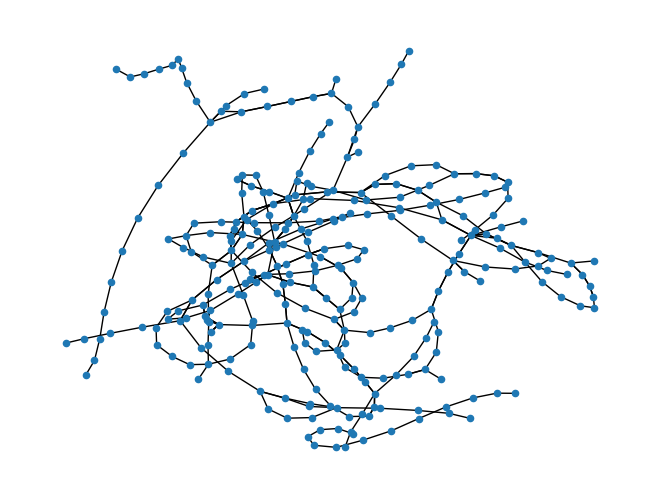

In [20]:
nx.draw(Bus_network, node_size = 20)
print(len(Bus_network.nodes))

197


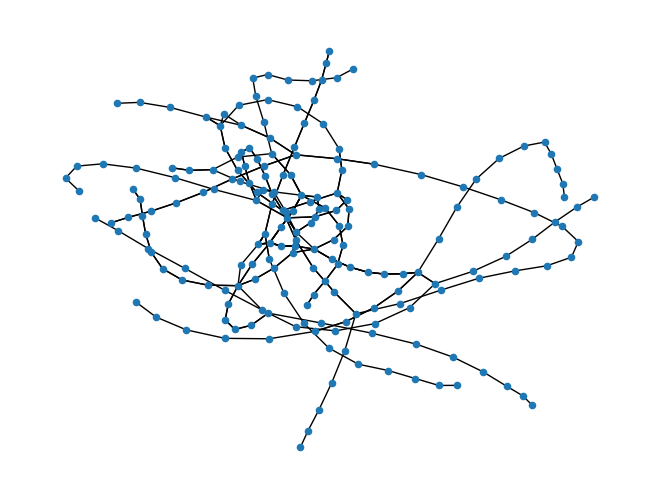

In [21]:
nx.draw(Tram_network, node_size = 20)
print(len(Tram_network.nodes))

In [22]:
C = []
Nodes_in_both = []
for node in Total_nodes:
    if node in Tram_network.nodes() and node in Bus_network.nodes():
        C.append(1)
        Nodes_in_both.append(node)
    else:
        C.append(0)


In [23]:
Layers = [Tram_network, Bus_network]
Layers_w = [Tram_network_w, Bus_network_w]
Layers_mat = [A_tram_mat, A_bus_mat]
Layers_mat_w = [W_tram_mat, W_bus_mat]

In [24]:
M_tram = np.asarray(A_tram_mat[A_tram_mat !=0])
M_tram = np.max(M_tram)
print(M_tram)

M_bus = np.asarray(A_bus_mat[A_bus_mat !=0])
M_bus = np.max(M_bus)
print(M_bus)

M = [M_tram, M_bus]

5.0
3.0


In [25]:
def P_alpha_alpha_ij(node_i, node_j, layer):
    p_ij = 0
    
    i = list(Layers[layer].nodes()).index(node_i)
    j = list(Layers[layer].nodes()).index(node_j)
    row_i = Layers_mat[layer][i]
    row_i_w = Layers_mat_w[layer][i]
    norm = ((Layers[layer].degree(node_i))**2)/(50*M[layer]) + np.sum(row_i[row_i != 0]/row_i_w[row_i_w != 0])

    if int(Layers_mat[layer][i][j]) == 0:
        
        if i == j:
            p_ij = (((Layers[layer].degree(node_i))**2)/(50*M[layer]))/norm
            return p_ij
        
        elif i != j:
            return p_ij
    
    elif int(Layers_mat[layer][i][j]) != 0:
        p_ij = (Layers_mat[layer][i][j]/Layers_mat_w[layer][i][j])/norm
        
    return p_ij
    

In [26]:
def P_alpha_beta_i(node_i, layer_a, layer_b):
    p_ab_i = 0
    
    
    if node_i not in Nodes_in_both:
        return p_ab_i
    else:
        tram_deg = Tram_network.degree(node_i)
        bus_deg = Bus_network.degree(node_i)
        total_deg = tram_deg + bus_deg
        
        if layer_a == 0 and layer_b == 1:
            p_ab_i = bus_deg/total_deg
           
            return p_ab_i 
        
        elif layer_a == 1 and layer_b == 0:
            p_ab_i = tram_deg/total_deg
            #print('Tram degree is:', tram_deg)
            #print('prob 1 to 0 is:', p_ab_i)
            return p_ab_i 
        
        elif layer_a == layer_b:
            p_ab_1 = P_alpha_alpha_ij(node_i, node_i, layer_a)
            return p_ab_i 
        

In [27]:
def P_alpha_beta_ij(node_i, node_j, layer_a, layer_b):
    p_ab_ij = 0
    
    if node_i != node_j and layer_a != layer_b:
        return p_ab_ij
    
    else:
        if node_i in Layers[0].nodes():
            norm_00 = np.sum([P_alpha_alpha_ij(node_i, node, 0) for node in list(Layers[0].neighbors(node_i))]) + P_alpha_alpha_ij(node_i, node_i, 0)
        else:
            norm_00 = 0
        
        if node_i in Layers[1].nodes():
            norm_11 = np.sum([P_alpha_alpha_ij(node_i, node, 1) for node in list(Layers[1].neighbors(node_i))]) + P_alpha_alpha_ij(node_i, node_i, 1)
        else:
            norm_11 = 0
        
        norm = norm_00 + norm_11 + P_alpha_beta_i(node_i, 0, 1) + P_alpha_beta_i(node_i, 1, 0) #+ P_alpha_alpha_ij(node_i, node_i, layer_a)
        
        if layer_a == layer_b:
            
            if node_i not in list(Layers[layer_a].nodes()) or node_j not in list(Layers[layer_a].nodes()):
                return p_ab_ij
            
            else:
                p_ab_ij = P_alpha_alpha_ij(node_i, node_j, layer_a)/norm
                return p_ab_ij
        
        elif layer_a != layer_b:

            p_ab_ij =  P_alpha_beta_i(node_i, layer_a, layer_b)/norm
            return p_ab_ij

In [28]:
def P_alpha_beta_ij_n(node_i, node_j, layer_a, layer_b):
    p_ab_ij = 0
    if node_i != node_j and layer_a != layer_b:
        return p_ab_ij
    
    else:
        if layer_a == 0:
            if node_i not in list(Tram_network.nodes()):
                return p_ab_ij
            else:
                norm = 1 + P_alpha_beta_i(node_i, 0, 1)/3
                
                if layer_b == 0:
                    
                    p_ab_ij = P_alpha_alpha_ij(node_i, node_j, 0)/norm
                    return p_ab_ij

                elif layer_b == 1:
                    
                    p_ab_ij = (P_alpha_beta_i(node_i, 0, 1)/3)/norm
                    return p_ab_ij
                    
        if layer_a == 1:
            if node_i not in list(Bus_network.nodes()):
                return p_ab_ij
            else:
                norm = 1 + P_alpha_beta_i(node_i, 1, 0)/10
                
                if layer_b == 1:
                    
                    p_ab_ij = P_alpha_alpha_ij(node_i, node_j, 1)/norm
                    return p_ab_ij

                elif layer_b == 0:
                    
                    p_ab_ij = (P_alpha_beta_i(node_i, 1, 0)/10)/norm
                    return p_ab_ij

    
    

In [29]:
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Milchbuck', 0, 0))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Milchbuck', 1, 0))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Milchbuck', 0, 1))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Milchbuck', 1, 1))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Hirschwiesenstrasse', 0, 0))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Guggachstrasse', 0, 0))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Universität Irchel', 0, 0))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Tierspital', 0, 0))
print('prob is:',P_alpha_beta_ij('Milchbuck', 'Bucheggplatz', 1, 1))



prob is: 0.02762192490289167
prob is: 0.24242424242424243
prob is: 0.0909090909090909
prob is: 0.05555555555555555
prob is: 0.07193209610128039
prob is: 0.1078981441519206
prob is: 0.07193209610128039
prob is: 0.0539490720759603
prob is: 0.2777777777777778


In [30]:
print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Milchbuck', 0, 0))
#print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Milchbuck', 1, 0))
print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Milchbuck', 0, 1))
#print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Milchbuck', 1, 1))
print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Hirschwiesenstrasse', 0, 0))
print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Guggachstrasse', 0, 0))
print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Universität Irchel', 0, 0))
print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Tierspital', 0, 0))
#print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Bucheggplatz', 1, 1))


prob is: 0.0759602934829521
prob is: 0.08333333333333333
prob is: 0.19781326427852108
prob is: 0.2967198964177817
prob is: 0.19781326427852108
prob is: 0.14835994820889084


In [31]:
list(Bus_network.neighbors('Bucheggplatz'))

['Brunnenhof',
 'Lägernstrasse',
 'Milchbuck',
 'Rosengartenstrasse',
 'Weihersteig']

In [32]:
#print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Bucheggplatz', 0, 0))
print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Bucheggplatz', 1, 0))
#print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Milchbuck', 0, 1))
print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Bucheggplatz', 1, 1))
print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Milchbuck', 1, 1))
print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Lägernstrasse', 1, 1))
print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Brunnenhof', 1, 1))
print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Weihersteig', 1, 1))
print('prob is:',P_alpha_beta_ij_n('Bucheggplatz', 'Rosengartenstrasse', 1, 1))

#print('prob is:',P_alpha_beta_ij_n('Milchbuck', 'Bucheggplatz', 1, 1))


prob is: 0.02439024390243903
prob is: 0.16001467506720196
prob is: 0.08889704170400108
prob is: 0.14816173617333514
prob is: 0.19754898156444683
prob is: 0.2963234723466703
prob is: 0.08466384924190579


In [33]:
P_alpha_beta_ij_n('Binz Center', 'Binz Center', 1, 0)

0.0

In [34]:
T_ker = np.zeros((197 + 293, 197 + 293))

for i in range(0, 197):
    loop_node = list(Tram_network.nodes())[i]
    T_ker[i][:197] = [P_alpha_beta_ij_n(loop_node, node_j, 0, 0) for node_j in list(Tram_network.nodes())]


In [35]:
for i in range(0, 293):
    loop_node = list(Bus_network.nodes())[i]
    T_ker[i + 197][197:] = [P_alpha_beta_ij_n(loop_node, node_j, 1, 1) for node_j in list(Bus_network.nodes())]

In [36]:
for i in range(0, 197):
    loop_node = list(Tram_network.nodes())[i]
    T_ker[i][197:] = [P_alpha_beta_ij_n(loop_node, node_j, 0, 1) for node_j in list(Bus_network.nodes())]

In [37]:
for i in range(0, 293):
    loop_node = list(Bus_network.nodes())[i]
    T_ker[197 + i][:197] = [P_alpha_beta_ij_n(loop_node, node_j, 1, 0) for node_j in list(Tram_network.nodes())]

In [38]:
def p_init_rw(length, pos):
    p_0 = np.zeros(length)
    p_0[pos] = 1
    return p_0

In [39]:
Double_nodes = list(Tram_network.nodes()) + list(Bus_network.nodes())

In [40]:
random_walker = rd.choice(Double_nodes)
rw_index = Double_nodes.index(random_walker)
print(random_walker)
print(rw_index)

p_0 = p_init_rw(len(Double_nodes), rw_index)

Albisrieden
26


In [41]:
for end in endstations:
    if end not in Double_nodes:
        print(end)

Schwammedingerplatz


In [42]:
test = endstations_3
test.remove(test[0])

In [43]:
testarr = np.array(range(1,5))
np.delete(testarr, 0)

array([2, 3, 4])

In [44]:
list(Bus_network.nodes()).index('Milchbuck')

104

In [45]:
Double_nodes[104 + 197]

'Milchbuck'

In [46]:
y = ['banana', 'apple']
x = y

x = x + ['orange', 'pear']

print(x)

['banana', 'apple', 'orange', 'pear']


In [47]:
def list_remover(list1, list2):
    new_list = []
    for element in list1:
        if element not in list2:
            new_list.append(element)
    return new_list

In [48]:
class Simulation():
    
    def __init__(self, Tram_network, Bus_network, Double_nodes, T_ker, t_end):
        self.Tram_network = Tram_network
        self.Bus_network = Bus_network
        self.Double_nodes = Double_nodes
        self.T_ker = T_ker
        self.random_walker = 'Milchbuck'
        self.rw_index = 104 + 197
        #self.rw_index = self.Double_nodes.index(self.random_walker)
        #self.rw_index = choice(np.array(range(0, len(self.Double_nodes))))
        #self.random_walker = self.Double_nodes[self.rw_index]
        #self.rw_index = list(self.Bus_network.nodes()).index(self.random_walker) + 197
        self.p_rw = p_init_rw(len(self.Double_nodes), self.rw_index)
        self.t_end = t_end
        self.pos_queue = [self.random_walker]
        self.index_queue = [self.rw_index]
        self.time_queue = []
        self.p_seq = [self.p_rw]
    
    
    def get_next_event(self):
        #print('the index before jumping is:', self.rw_index)
        p_new = np.matmul(self.p_rw, T_ker)
        row_rw = self.T_ker[self.rw_index]
        substract = np.zeros(len(row_rw))
        swap = 0
        if self.rw_index < 197:
            
            if self.random_walker in list(Bus_network.nodes()):

                rw_index_bus = list(self.Bus_network.nodes()).index(self.random_walker)
                #print('index bus is:', rw_index_bus)
                candidates = [self.random_walker] + list(self.Tram_network.neighbors(self.random_walker))
                substract[self.rw_index] = - P_alpha_beta_ij_n(self.random_walker, self.random_walker, 0, 1)
                substract[rw_index_bus + 197] = P_alpha_beta_ij_n(self.random_walker, self.random_walker, 0, 1)
                p = row_rw - substract
                p = p[p != 0]
                if len(p[p < 0]) > 0:
                    p = p[p >= 0]
                    p = np.delete(p, 0)
                    candidates.remove(self.random_walker)
                #print(candidates)
                
                prob = p/(np.sum(p))
                #print(prob)
                next_pos = choice(candidates, 1, p = prob)
                next_pos = next_pos[0]
                new_index = self.Double_nodes.index(next_pos)
                
                if new_index == self.rw_index:
                    bern_norm = P_alpha_beta_ij_n(self.random_walker, self.random_walker, 0, 1) + P_alpha_beta_ij_n(self.random_walker, self.random_walker, 0, 0)
                    bernoulli = [P_alpha_beta_ij_n(self.random_walker, self.random_walker, 0, 1)/bern_norm, P_alpha_beta_ij_n(self.random_walker, self.random_walker, 0, 0)/bern_norm]
                    new_index = choice([rw_index_bus + 197, self.rw_index], 1, p = bernoulli)
                    new_index = new_index[0]
                    
                    if new_index >= 197:
                        print('Switched from tram to bus at:', next_pos)
                        row_new = self.T_ker[new_index]
                        row_new[self.rw_index] = 0
                        row_new[new_index] = 0
                        row_new = row_new/(np.sum(row_new))
                        self.T_ker[new_index] = row_new
                        #print('the index after the jump is:',new_index)
                        
                return [next_pos, new_index]
            
            else:
                candidates = [self.random_walker] + list(self.Tram_network.neighbors(self.random_walker))
                p = row_rw[row_rw != 0]
                prob = p/(np.sum(p))
                #print(candidates)
                #print(prob)
                next_pos = choice(candidates, 1, p = prob)
                next_pos = next_pos[0]
                new_index = self.Double_nodes.index(next_pos)
                
                return [next_pos, new_index]
                
        else:
            
            if self.random_walker in list(Tram_network.nodes()):
                #print('here!')
                rw_index_tram = list(self.Tram_network.nodes()).index(self.random_walker)
                candidates = [self.random_walker] + list(self.Bus_network.neighbors(self.random_walker))
                
                substract[self.rw_index] = - P_alpha_beta_ij_n(self.random_walker, self.random_walker, 1, 0)
                substract[rw_index_tram] = P_alpha_beta_ij_n(self.random_walker, self.random_walker, 1, 0)
                p = row_rw - substract
                #print(row_rw[self.rw_index])
                #print(row_rw[rw_index_tram])
                #print(substract[self.rw_index])
                #print(substract[rw_index_tram])
                p = p[p != 0]
                #print(p)
                if len(p[p < 0]) > 0:
                    p = p[p > 0]
                    p = np.delete(p, 0)                    
                    candidates.remove(self.random_walker)
                    #if len(p) != len(candidates):
                        #p = np.delete(p, 0) 

                prob = p/(np.sum(p))
                #print(candidates)
                #print(prob)
                next_pos = choice(candidates, 1, p = prob)
                next_pos = next_pos[0]
                new_index = list(self.Bus_network.nodes()).index(next_pos)
                
                
                if self.Double_nodes[new_index + 197] == self.Double_nodes[self.rw_index]:
                    bern_norm = P_alpha_beta_ij_n(self.random_walker, self.random_walker, 1, 0) + P_alpha_beta_ij_n(self.random_walker, self.random_walker, 1, 1)
                    bernoulli = [P_alpha_beta_ij_n(self.random_walker, self.random_walker, 1, 0)/bern_norm, P_alpha_beta_ij_n(self.random_walker, self.random_walker, 1, 1)/bern_norm]
                    new_index = choice([rw_index_tram, self.rw_index], 1, p = bernoulli)
                    new_index = new_index[0]
                    #print(new_index)
                    if new_index < 197:
                        print('Switched from bus to tram at:', next_pos)
                        row_new = self.T_ker[new_index]
                        row_new[self.rw_index] = 0
                        row_new[new_index] = 0                        
                        row_new = row_new/(np.sum(row_new))
                        self.T_ker[new_index] = row_new
                
                else:
                    new_index = new_index + 197
                    
                return [next_pos, new_index]
            
            else:
                candidates = [self.random_walker] + list(self.Bus_network.neighbors(self.random_walker))
                p = row_rw[row_rw != 0]
                prob = p/(np.sum(p))
                #print(candidates)
                #print(prob)
                next_pos = choice(candidates, 1, p = prob)
                next_pos = next_pos[0]
                new_index = list(self.Bus_network.nodes()).index(next_pos) + 197
                
                return [next_pos, new_index]
            
        
    def initialize_events(self):
        
        [next_pos, new_index] = Simulation.get_next_event(self)
        
        if len(self.pos_queue) >= 3 and (next_pos == self.pos_queue[-2] or next_pos == self.pos_queue[-3]) and next_pos not in endstations:
            #print('repeat')
            Simulation.initialize_events(self)
            
            #if len(T_ker[new_index][T_ker[new_index] != 0]) < 3:
                
        elif next_pos in endstations and len(self.T_ker[new_index][self.T_ker[new_index] != 0]) < 3:
            #print('Arrived at end stop:', next_pos)
            self.pos_queue.append(next_pos)
            self.index_queue.append(new_index)
        #    return 'End of random walk'
        else:
            self.pos_queue.append(next_pos)
            self.index_queue.append(new_index)
    
    
    def run(self):
        
        Simulation.initialize_events(self)
        t = 0
        
        while t <= self.t_end:
            #print('we are at time:', t)
            self.rw_index = self.index_queue[-1]
            self.random_walker = self.pos_queue[-1]
            
#            if len(self.pos_queue) < 3:
            Simulation.initialize_events(self)
    
            if self.pos_queue[-1] in endstations and len(T_ker[self.index_queue[-1]][T_ker[self.index_queue[-1]] != 0]) < 3:
                print('Arrived at end stop:', self.pos_queue[-1])
                #print('End of random walk')
                tp_point = choice(list_remover(Total_nodes, self.pos_queue), 1)
                tp_point = tp_point[0]
                tp_index = Double_nodes.index(tp_point)
                self.pos_queue.append(tp_point)
                self.index_queue.append(tp_index)
                print('jumped to:', tp_point)
                
#            else:
#                Simulation.initialize_events(self)
#                if self.random_walker == self.pos_queue[-3]:
#                    self
#                    continue
            t = t+1
#            
        return self.pos_queue, self.index_queue
        

In [1]:
random_walk1 = Simulation(Tram_network, Bus_network, Double_nodes, T_ker, 1000)
print(random_walk1.random_walker)
print(random_walk1.rw_index)
[pos_queue, index_queue] = Simulation.run(random_walk1)
#print(pos_queue)
print(len(set(pos_queue)))


































print(pos_queue)

NameError: name 'Simulation' is not defined